In [618]:
import numpy as np
import pandas as pd
import requests
from io import StringIO
import datetime as dt

import statsmodels.api as sts

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(r'C:\Users\USER\Documents\Programación\Investment_strategy')
import Investment_tools as it

import yfinance as yf

import matplotlib.pyplot as plt

## Data Scraping

In [461]:
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {"User-Agent": 'Mozilla/5.0 (learning project)'}

In [462]:
response = requests.get(url= url, headers= headers)
response.raise_for_status()

In [463]:
# Get the table

data = pd.read_html(StringIO(response.text), attrs= {'id':'constituents'})
data = data[0]

In [464]:
data.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## EDA

In [465]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 503 non-null    object
 1   Security               503 non-null    object
 2   GICS Sector            503 non-null    object
 3   GICS Sub-Industry      503 non-null    object
 4   Headquarters Location  503 non-null    object
 5   Date added             503 non-null    object
 6   CIK                    503 non-null    int64 
 7   Founded                503 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.6+ KB


In [466]:
# Changing name of columns

data= data.rename(columns= {'Date added':'Date_added', 'Symbol': 'Ticker', 'GICS Sector': 'GICS_sector', 'GICS Sub-Industry':'GICS_subindustry', 'Headquarters Location': 'Headquarters'})

In [467]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Ticker            503 non-null    object
 1   Security          503 non-null    object
 2   GICS_sector       503 non-null    object
 3   GICS_subindustry  503 non-null    object
 4   Headquarters      503 non-null    object
 5   Date_added        503 non-null    object
 6   CIK               503 non-null    int64 
 7   Founded           503 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.6+ KB


In [468]:
# Cleaning "founded" column

data['Founded'] = data['Founded'].apply(lambda x: x[0:4])

In [469]:
# Setting corresponding data types

data['Date_added'] = pd.to_datetime(data['Date_added'])
data['Founded'] = pd.to_datetime(data['Founded'], format= '%Y').dt.to_period('Y')

In [470]:
# Creating year date column

data['Year_added'] = data['Date_added'].dt.to_period('Y')

## QUESTIONS

Question 1: Which year had the highest number of additions (starting from 2020)?

In [471]:
data[data['Year_added'] >= "2025"].groupby('Year_added')['Ticker'].count()

Year_added
2025    17
2026    16
Freq: Y-DEC, Name: Ticker, dtype: int64

Question 2: How many indexes (out of 10) have better year-to-date returns than the US (S&P 500) as of August 21, 2026?

In [472]:
ticker = [
    '^GSPC',
    '000001.SS',
    '^HSI',
    '^AXJO',
    '^NSEI',
    '^GSPTSE',
    '^GDAXI',
    '^FTSE',
    '^N225',
    '^MXX',
    '^BVSP'
    ]

start_date = '2026-01-01'
end_date = '2026-08-21'

In [473]:
returns = yf.download(tickers= ticker, start= start_date, end= end_date)['Close'].pct_change().dropna()

[*********************100%***********************]  11 of 11 completed
C:\Users\USER\AppData\Local\Temp\ipykernel_2164\1005550872.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = yf.download(tickers= ticker, start= start_date, end= end_date)['Close'].pct_change().dropna()


In [474]:
returns.apply(lambda x: (x+1).prod(), axis= 0).sort_values(ascending=False)

Ticker
^N225        1.277507
^GSPTSE      1.128659
^GSPC        1.107086
^FTSE        1.074326
^GDAXI       1.044809
^AXJO        1.040694
^BVSP        1.037419
^MXX         0.989778
^HSI         0.975377
000001.SS    0.970250
^NSEI        0.923108
dtype: float64

Question 3: Calculate the median drawdown (in %) of significant market corrections in the S&P 500 index.

In [475]:
ticker = [
    '^GSPC'
    ]

start_date = '1950-01-01'
end_date = '2026-08-21'

In [476]:
returns = yf.download(tickers= ticker, start= start_date, end= end_date)['Close'].pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [477]:
mid_drawdown = it.drawdown(returns['^GSPC'])

In [478]:
mid_drawdown['Difference'] = mid_drawdown['Wealth_index'] - mid_drawdown['Previous_peaks']
mid_drawdown['Difference%'] = abs(np.divide(mid_drawdown['Difference'],mid_drawdown['Previous_peaks']))

In [479]:
THRESHOLD = 0.05                      # 5% (Difference% is a fraction: 0.05 = 5%)

dd = mid_drawdown["Difference%"]
in_dd = dd > 0                        # True while we are underwater

# --- Step 1: give every drawdown cluster an ID ---------------------------
starts = in_dd & ~in_dd.shift(fill_value=False)   # first row of each cluster
cluster_id = starts.cumsum().where(in_dd)         # 1,1,1,2,2,... ; NaN on zero rows

# --- Step 2: column 1, max drawdown of the cluster (if > 5%) -------------
cluster_max = dd.groupby(cluster_id).transform("max")
mid_drawdown["Max_DD_cluster"] = np.where(cluster_max > THRESHOLD, cluster_max, 0.0)

# --- Step 3: extend each cluster by its recovery row ----------------------
# The recovery row is the first zero right after a cluster (peak touched again)
recovery = ~in_dd & in_dd.shift(fill_value=False)
ext_id = cluster_id.copy()
ext_id[recovery] = cluster_id.ffill()[recovery]

# --- Step 4: mark the trough (worst day) of each cluster ------------------
ext_max = dd.groupby(ext_id).transform("max")
is_trough = in_dd & (dd == ext_max)
first_trough = is_trough & (is_trough.astype(int).groupby(ext_id).cumsum() == 1)  # first one if ties

# --- Step 5: column 2, days counted from the trough to recovery -----------
after_trough = first_trough.astype(int).groupby(ext_id).cumsum() > 0   # False before trough, True from it
days = after_trough.astype(int).groupby(ext_id).cumsum() - 1           # trough = 0, next = 1, ...
days = days.clip(lower=0).fillna(0)

days = days.where(ext_max > THRESHOLD, 0)     # only clusters deeper than 5%

# Optional: a cluster still open at the end of the data has not recovered yet
if in_dd.iloc[-1]:
    days = days.mask(ext_id == cluster_id.iloc[-1])   # becomes NaN

mid_drawdown["Days_to_recover"] = days

In [480]:
cluster_id.head(40)

Date
1950-01-04    NaN
1950-01-05    NaN
1950-01-06    NaN
1950-01-09    NaN
1950-01-10    1.0
1950-01-11    NaN
1950-01-12    2.0
1950-01-13    2.0
1950-01-16    2.0
1950-01-17    2.0
1950-01-18    2.0
1950-01-19    2.0
1950-01-20    2.0
1950-01-23    2.0
1950-01-24    2.0
1950-01-25    2.0
1950-01-26    2.0
1950-01-27    2.0
1950-01-30    2.0
1950-01-31    2.0
1950-02-01    2.0
1950-02-02    NaN
1950-02-03    NaN
1950-02-06    NaN
1950-02-07    3.0
1950-02-08    3.0
1950-02-09    3.0
1950-02-10    3.0
1950-02-14    3.0
1950-02-15    3.0
1950-02-16    3.0
1950-02-17    3.0
1950-02-20    3.0
1950-02-21    3.0
1950-02-23    3.0
1950-02-24    3.0
1950-02-27    3.0
1950-02-28    3.0
1950-03-01    3.0
1950-03-02    3.0
Name: Difference%, dtype: float64

In [481]:
dd = mid_drawdown[mid_drawdown['Difference%']>0.05]

In [482]:
Max_dd_values = dd['Max_DD_cluster'].unique()
Max_dd_id = []

for i in Max_dd_values:
    id = dd[dd['Difference%'] == i].index
    Max_dd_id.append(id)
''
Day_recover = dd[['Max_DD_cluster', 'Days_to_recover']].groupby('Max_DD_cluster').max()['Days_to_recover'].values

pd.DataFrame({
    'Date': [idx[0].strftime('%Y-%m-%d') for idx in Max_dd_id],
    'Max_dd': Max_dd_values,
    'Days_recover': Day_recover
})


,Date,Max_dd,Days_recover
0,1950-07-17,0.140206,0.0
1,1950-12-04,0.064961,0.0
2,1951-06-29,0.081105,0.0
3,1951-11-23,0.060797,0.0
4,1952-02-20,0.063666,0.0
...,...,...,...
69,2024-04-19,0.054644,86.0
70,2024-08-05,0.084851,424.0
71,2025-04-08,0.189022,1444.0
72,2025-11-20,0.051101,1133.0


Question 4: Calculate the median 2-day percentage change in stock prices following positive earnings surprise days.

In [542]:
ticker = 'AMZN'

start_date = '2020-10-27'
end_date = '2026-08-21'

In [543]:
returns = yf.download(tickers= ticker, start= start_date, end= end_date)['Close'].pct_change()

[*********************100%***********************]  1 of 1 completed


In [544]:
earnings = yf.Ticker(ticker).get_earnings_dates()

In [545]:
earnings.index = [idx.strftime('%Y-%m-%d') for idx in earnings.index]
earnings.index = pd.to_datetime(earnings.index)

In [546]:
returns['EPS_rel'] = returns.index.isin(earnings.index)

In [547]:
returns['AMZN'] = (returns['AMZN']+1).cumprod()
        

In [557]:
# 1. Get the return from the row before, and the row after, every row
prev_return = returns['AMZN'].shift(1)
next_return = returns['AMZN'].shift(-1)

# 2. Percentage change between "before" and "after"
pct_change = (next_return - prev_return) / prev_return

# 3. Keep that value only on the earnings rows; everything else is NaN
returns['2day'] = pct_change.where(returns['EPS_rel'], 0)
returns['2day'] = returns['2day'].shift(1)

returns = returns.dropna()

In [573]:
x = returns[returns['2day']>0]['2day']

In [593]:
y = earnings[earnings.index.isin(x.index - pd.Timedelta(days= 1))]['Reported EPS']

In [616]:
x_cons = sts.add_constant(x.values)

model = sts.OLS(y.values,x_cons).fit()

In [617]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.069
Date:                Fri, 25 Sep 2026   Prob (F-statistic):              0.326
Time:                        00:43:08   Log-Likelihood:                -21.060
No. Observations:                  12   AIC:                             46.12
Df Residuals:                      10   BIC:                             47.09
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0615      0.677      3.044      0.012       0.553       3.570
x1            -8.4369      8.162     -1.034      0.326     -26.623       9.749
==============================================================================
Omnibus:                        9.062   Durbin-Watson:                   0.552
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                4.473
Skew:                           1.287   Prob(JB):                        0.107
Kurtosis:                       4.525   Cond. No.                         18.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: >

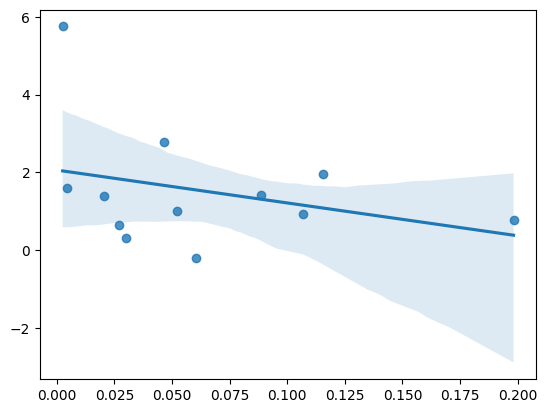

In [620]:
sns.regplot(x= x.values, y= y.values)